<table align = "center" width = 100%>
   <tr>
       </td>
           </td>
       </td>
       <td>
          <div align = "center">
               <font color = "#21618C" size = 8px>
                          <b>Data Analysis on TCS stock Dataset.</b>
               </font>
          </div>
        </td>
    <tr>
</table>

**Problem Statement:- The objective of this project is to analyze the historical data of TCS stock to gain insights into stock behavior, identify
trends, and forecast future stock prices.**

### Importing Necessary Libraries

In [1]:
# pandas library for accessing data structures which helps in loading and handling the dataset.
import pandas as pd

# Numpy library to perform certain mathematical operations and accessing numpy array
import numpy as np

# Matplotlib library for plotting graphs for analysis and visualization of the data
import matplotlib.pyplot as plt

# Seaborn library for plotting more dynamic and visually appealing graphs
import seaborn as sns

# Standard Scaler for scaling the numerical columns
from sklearn.preprocessing import StandardScaler

# To Split the dataset
from sklearn.model_selection import train_test_split

# Importing the models for training
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Libraries for performing NLP tasks
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Importing the Accuracy checking metrices
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model for Hyperparameter tuning of models
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# To access 'filterwarnings' function to ignore the warnings
import warnings

In [2]:
# Setting max columns option, so that it will be able to display all the columns of the dataset
pd.set_option("display.max_columns", None)

# Setting max rows option, so that it will be able to display all the rows of the dataset
pd.set_option("display.max_rows", None)

# Step-1: Data Overview

In [ ]:
# This method is for ignoring the warnings
warnings.filterwarnings('ignore')

# loading the dataset
df_tcs_stock_data = pd.read_csv("../data/TCS_stock_history.csv")

In [4]:
# Checking columns and rows of the dataset
No_of_rows, No_of_columns = df_tcs_stock_data.shape

#Printing number of columns
print("Number of Columns:",No_of_columns)

#Printing number of rows
print("Number of Rows:",No_of_rows)

Number of Columns: 8
Number of Rows: 4463


In [5]:
df_tcs_stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          4463 non-null   object 
 1   Open          4463 non-null   float64
 2   High          4463 non-null   float64
 3   Low           4463 non-null   float64
 4   Close         4463 non-null   float64
 5   Volume        4463 non-null   int64  
 6   Dividends     4463 non-null   float64
 7   Stock Splits  4463 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 279.1+ KB


## **About the dataset (TCS stock dataset)**
The data set contains 4,463 observations. Information about the columns are given below.

#### Data Dictionary
- **`Date`**: This column represents the **Date** on which that particular record was created.
  
- **`Open`**: This column represents the Opening stock price on that day.
- **`High`**: Highest stock price of the day.
- **`Low`**: Lowest stock price of the day.
- **`Close`**: Closing stock price of the day.
- **`Volume`**: Number of shares traded.
- **`Dividends`**: Dividends paid on the stock.
- **`Stock Splits`**: Number of stock splits.

**Interpretation**

From this we can see that:
- There are **7 Numerical columns**.
- And there is **1 Date time** type column **`Date`**.

# Step-2: Data Preprocessing

## a) Null value Handling

In [6]:
# Checking how many null values are present in the dataset
df_tcs_stock_data.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

**Interpretation**

Here we can see that there are no columns with any null values.

## b) Handling duplicate records

In [7]:
# Checking for number of duplicate records in the dataset
df_tcs_stock_data.duplicated().sum()

0

**Interpretation**

As we can see there are no duplicate records

## c) Correcting the datatypes and values according to the datatypes of the columns

In [8]:
# Splitting the 'Date' column into 'Recorded_Time', 'Recorded_Day_of_the_Week', 'Recorded_Month', 'Recorded_Year'

# Converting the 'Date' column to datetime datatype
df_tcs_stock_data['Date'] = pd.to_datetime(df_tcs_stock_data['Date'], errors='coerce')

# Extracting 'Recorded_Day_of_the_Week' column
df_tcs_stock_data['Recorded_Day_of_the_Week'] = df_tcs_stock_data['Date'].dt.dayofweek # (0 = Monday, 6 = Sunday)

# Extracting 'Recorded_Month' column
df_tcs_stock_data['Recorded_Month'] = df_tcs_stock_data['Date'].dt.month

# Extracting 'Recorded_Year' column
df_tcs_stock_data['Recorded_Year'] = df_tcs_stock_data['Date'].dt.year

In [9]:
df_tcs_stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      4463 non-null   datetime64[ns]
 1   Open                      4463 non-null   float64       
 2   High                      4463 non-null   float64       
 3   Low                       4463 non-null   float64       
 4   Close                     4463 non-null   float64       
 5   Volume                    4463 non-null   int64         
 6   Dividends                 4463 non-null   float64       
 7   Stock Splits              4463 non-null   float64       
 8   Recorded_Day_of_the_Week  4463 non-null   int32         
 9   Recorded_Month            4463 non-null   int32         
 10  Recorded_Year             4463 non-null   int32         
dtypes: datetime64[ns](1), float64(6), int32(3), int64(1)
memory usage: 331.4 KB


**Interpretation**

As we can see, the new columns extracting **day of the week**, **month** and **year** have been extracted. 

In [10]:
# Checking for null values, if this new columns' generation has caused any
df_tcs_stock_data.isnull().sum()

Date                        0
Open                        0
High                        0
Low                         0
Close                       0
Volume                      0
Dividends                   0
Stock Splits                0
Recorded_Day_of_the_Week    0
Recorded_Month              0
Recorded_Year               0
dtype: int64

**Interpretation**

No new null values are introduced.

In [11]:
# Reducing the float values of columns with float datatypes to '2' decimal points or either to integer, according to the need

for column in df_tcs_stock_data.columns[df_tcs_stock_data.dtypes == np.number]:
    df_tcs_stock_data[column] = df_tcs_stock_data[column].round(2)

In [12]:
# Checking if the changes have occurred or not by printing first five values of the dataset
df_tcs_stock_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Recorded_Day_of_the_Week,Recorded_Month,Recorded_Year
0,2002-08-12,28.79,29.74,28.79,29.52,212976,0.0,0.0,0,8,2002
1,2002-08-13,29.56,30.03,28.91,29.12,153576,0.0,0.0,1,8,2002
2,2002-08-14,29.18,29.18,26.56,27.11,822776,0.0,0.0,2,8,2002
3,2002-08-15,27.11,27.11,27.11,27.11,0,0.0,0.0,3,8,2002
4,2002-08-16,26.97,28.26,26.58,27.05,811856,0.0,0.0,4,8,2002


**Interpretation**

As we can see here the float values of the certain columns which had more than 2 values after decimal point are reduced to 2 values.

In [13]:
df_tcs_stock_data[['Date', 'Dividends', 'Stock Splits']].nunique()

Date            4463
Dividends         29
Stock Splits       2
dtype: int64

**Interpretation**

Here we can see that these columns **`Date`** and **`Stock Splits`** have almost all the values as unique or very less unique values. Meaning they may not contain hidden patterns so we will remove them before training our model, also **`Stock Splits`** column may not have pattern so we will decide whether to remove it or not in further stages

# Step 3: EDA (Exploratory Data Analysis)

## a) Bivariate Analysis

Here we are going to plot graphs for pairs of columns, we'll make the pairs with target column **`Close`**.

### 1. Numerical-Numerical column pairs

#### 1. Open vs Close

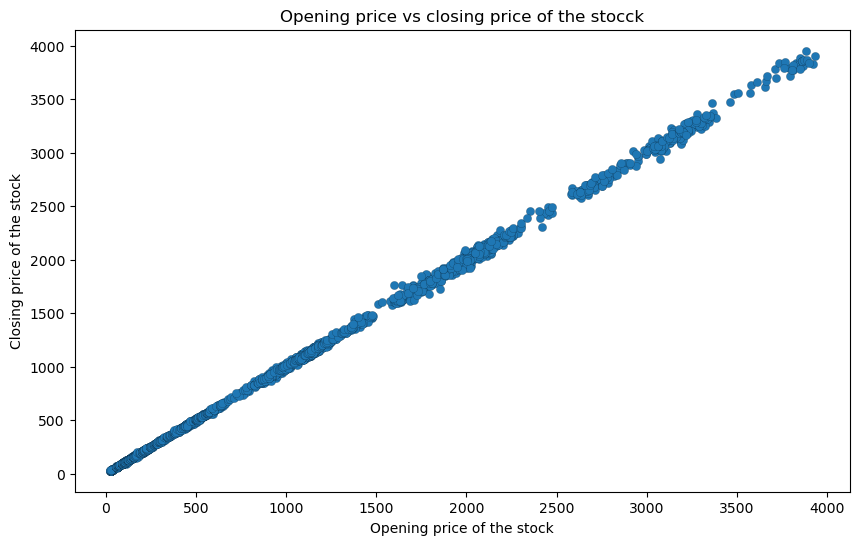

In [14]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "Open", y = "Close", data = df_tcs_stock_data, edgecolor = "black", linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("Opening price of the stock")

# Setting the name of y axis
ax.set_ylabel("Closing price of the stock")

# Setting the title
ax.set_title("Opening price vs closing price of the stocck")

# Displaying the graph
plt.show()

**Interpretation**

- We can see that there is a **very strong positive relationship** between **Opening and Closing price** of a stock. 

#### 2. High vs Close

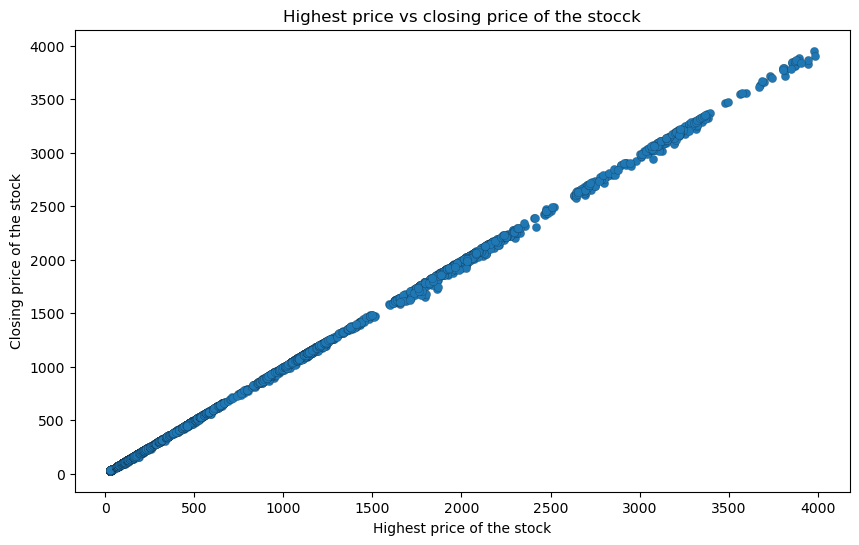

In [15]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "High", y = "Close", data = df_tcs_stock_data, edgecolor = "black", linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("Highest price of the stock")

# Setting the name of y axis
ax.set_ylabel("Closing price of the stock")

# Setting the title
ax.set_title("Highest price vs closing price of the stocck")

# Displaying the graph
plt.show()

**Interpretation**

- We can see that there is a **very strong positive relationship** between **Highest price and Closing price** of a stock. 

#### 3. Low vs Close

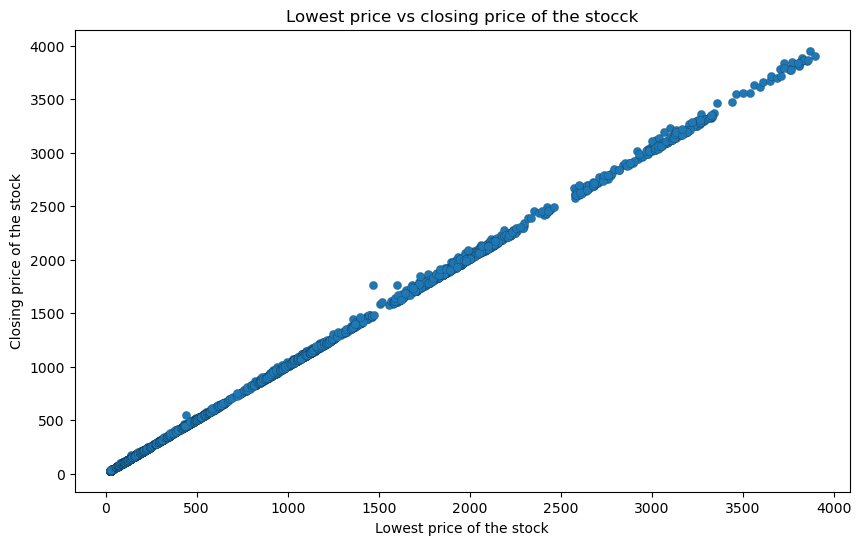

In [16]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "Low", y = "Close", data = df_tcs_stock_data, edgecolor = "black", linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("Lowest price of the stock")

# Setting the name of y axis
ax.set_ylabel("Closing price of the stock")

# Setting the title
ax.set_title("Lowest price vs closing price of the stocck")

# Displaying the graph
plt.show()

**Interpretation**

- We can see that there is a **very strong positive relationship** between **Lowest price and Closing price** of a stock. 

#### 4. Volume vs Close

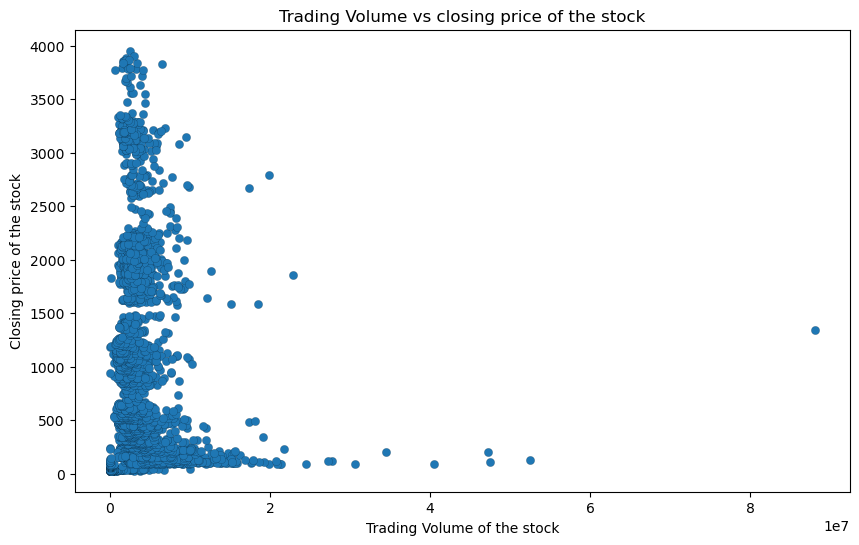

In [17]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "Volume", y = "Close", data = df_tcs_stock_data, edgecolor = "black", linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("Trading Volume of the stock")

# Setting the name of y axis
ax.set_ylabel("Closing price of the stock")

# Setting the title
ax.set_title("Trading Volume vs closing price of the stock")

# Displaying the graph
plt.show()

**Interpretation**

- Here though we are not able to find a significant pattern or relationship.

#### 5. Dividends vs Close

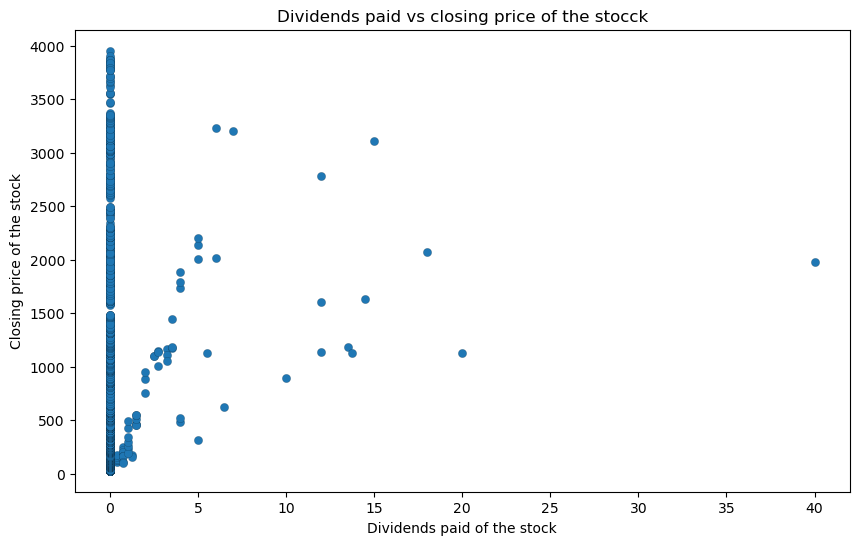

In [18]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "Dividends", y = "Close", data = df_tcs_stock_data, edgecolor = "black", linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("Dividends paid of the stock")

# Setting the name of y axis
ax.set_ylabel("Closing price of the stock")

# Setting the title
ax.set_title("Dividends paid vs closing price of the stocck")

# Displaying the graph
plt.show()

**Interpretation**

- We can see for most of the stocks dividend is zero only, and there is rough pattern that as the price increases the dividend also increases.

#### 6. Stock Splits vs Close

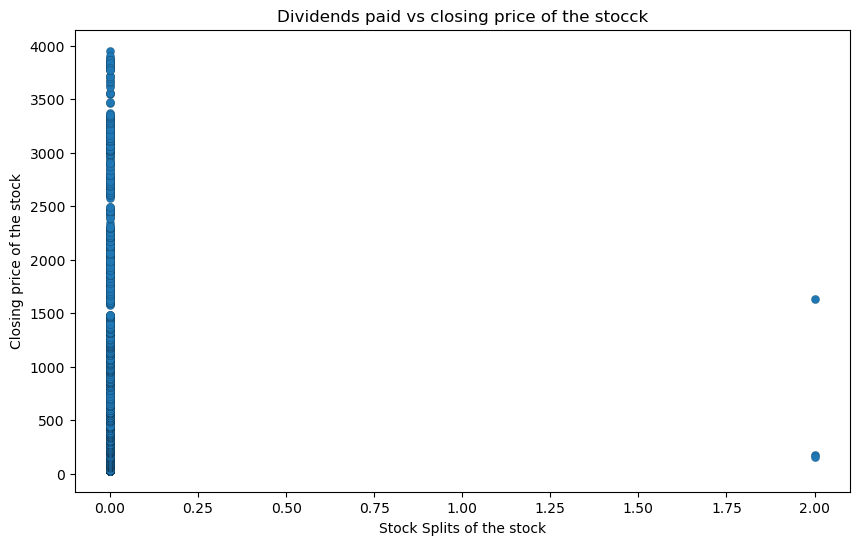

In [19]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "Stock Splits", y = "Close", data = df_tcs_stock_data, edgecolor = "black", linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("Stock Splits of the stock")

# Setting the name of y axis
ax.set_ylabel("Closing price of the stock")

# Setting the title
ax.set_title("Dividends paid vs closing price of the stocck")

# Displaying the graph
plt.show()

**Interpretation**

We can see here that there are only 2 stocks which did stock splits and also splitted the stock in only 2 splits. So this column should be dropped because it has all the values as same only.

#### 7. Recorded_Day_of_the_Week vs Close

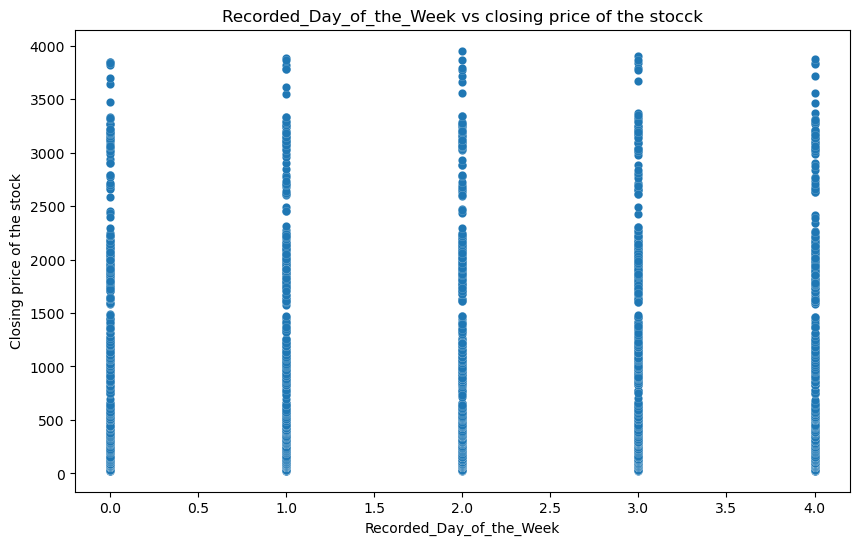

In [20]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "Recorded_Day_of_the_Week", y = "Close", data = df_tcs_stock_data, linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("Recorded_Day_of_the_Week")

# Setting the name of y axis
ax.set_ylabel("Closing price of the stock")

# Setting the title
ax.set_title("Recorded_Day_of_the_Week vs closing price of the stocck")

# Displaying the graph
plt.show()

**Interpretation**

Here we can see that there is no clear pattern again visible.

#### 8. Recorded_Month vs Close

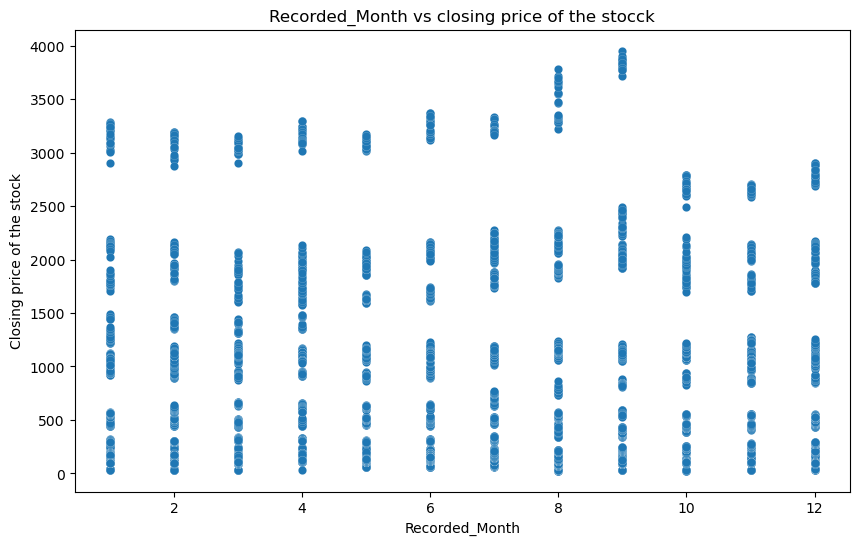

In [21]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "Recorded_Month", y = "Close", data = df_tcs_stock_data, linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("Recorded_Month")

# Setting the name of y axis
ax.set_ylabel("Closing price of the stock")

# Setting the title
ax.set_title("Recorded_Month vs closing price of the stocck")

# Displaying the graph
plt.show()

#### 9. Recorded_Year vs Close

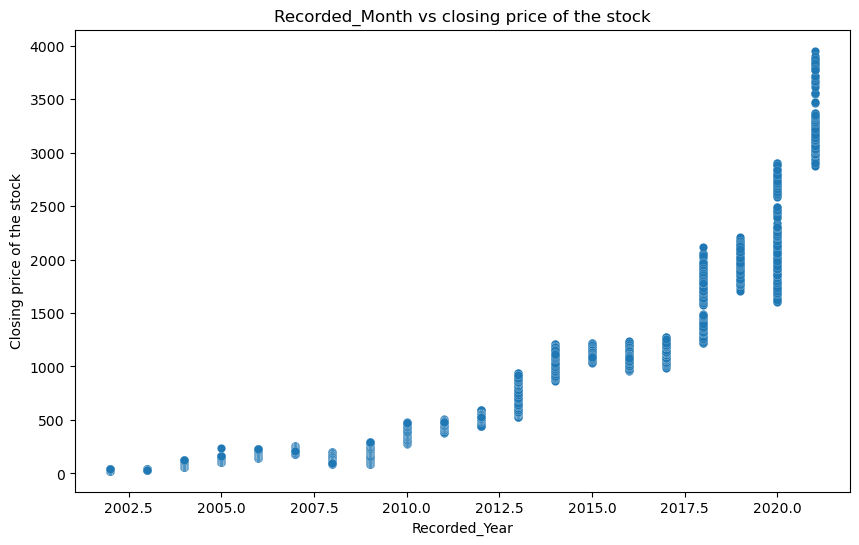

In [22]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "Recorded_Year", y = "Close", data = df_tcs_stock_data, linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("Recorded_Year")

# Setting the name of y axis
ax.set_ylabel("Closing price of the stock")

# Setting the title
ax.set_title("Recorded_Month vs closing price of the stock")

# Displaying the graph
plt.show()

**Interpretation**

Here we can see that there is a clear pattern, that over time the stock price has increased only.

# Step 4: Preparing the data for Machine Learning

## 1. Feature Selection

Here we will remove some of the features we already know are not useful, which we found from the above sections.

### a. Dropping the columns

In [23]:
columns_to_be_dropped = ["Date", "Stock Splits"]

df_tcs_stock_data.drop(columns = columns_to_be_dropped, axis = 1, inplace = True)

**Interpretation**

Now we have dropped all the unwanted columns and now we will proceed ahead.

## 2. Outlier Treatment

We will first make a **Statistical description table** of all the numerical columns of the dataframe, then we will see the difference between **mean** and **median** of each column, which will tell us whether **outliers** are present in a particular column or not. Then treat them accordingly.

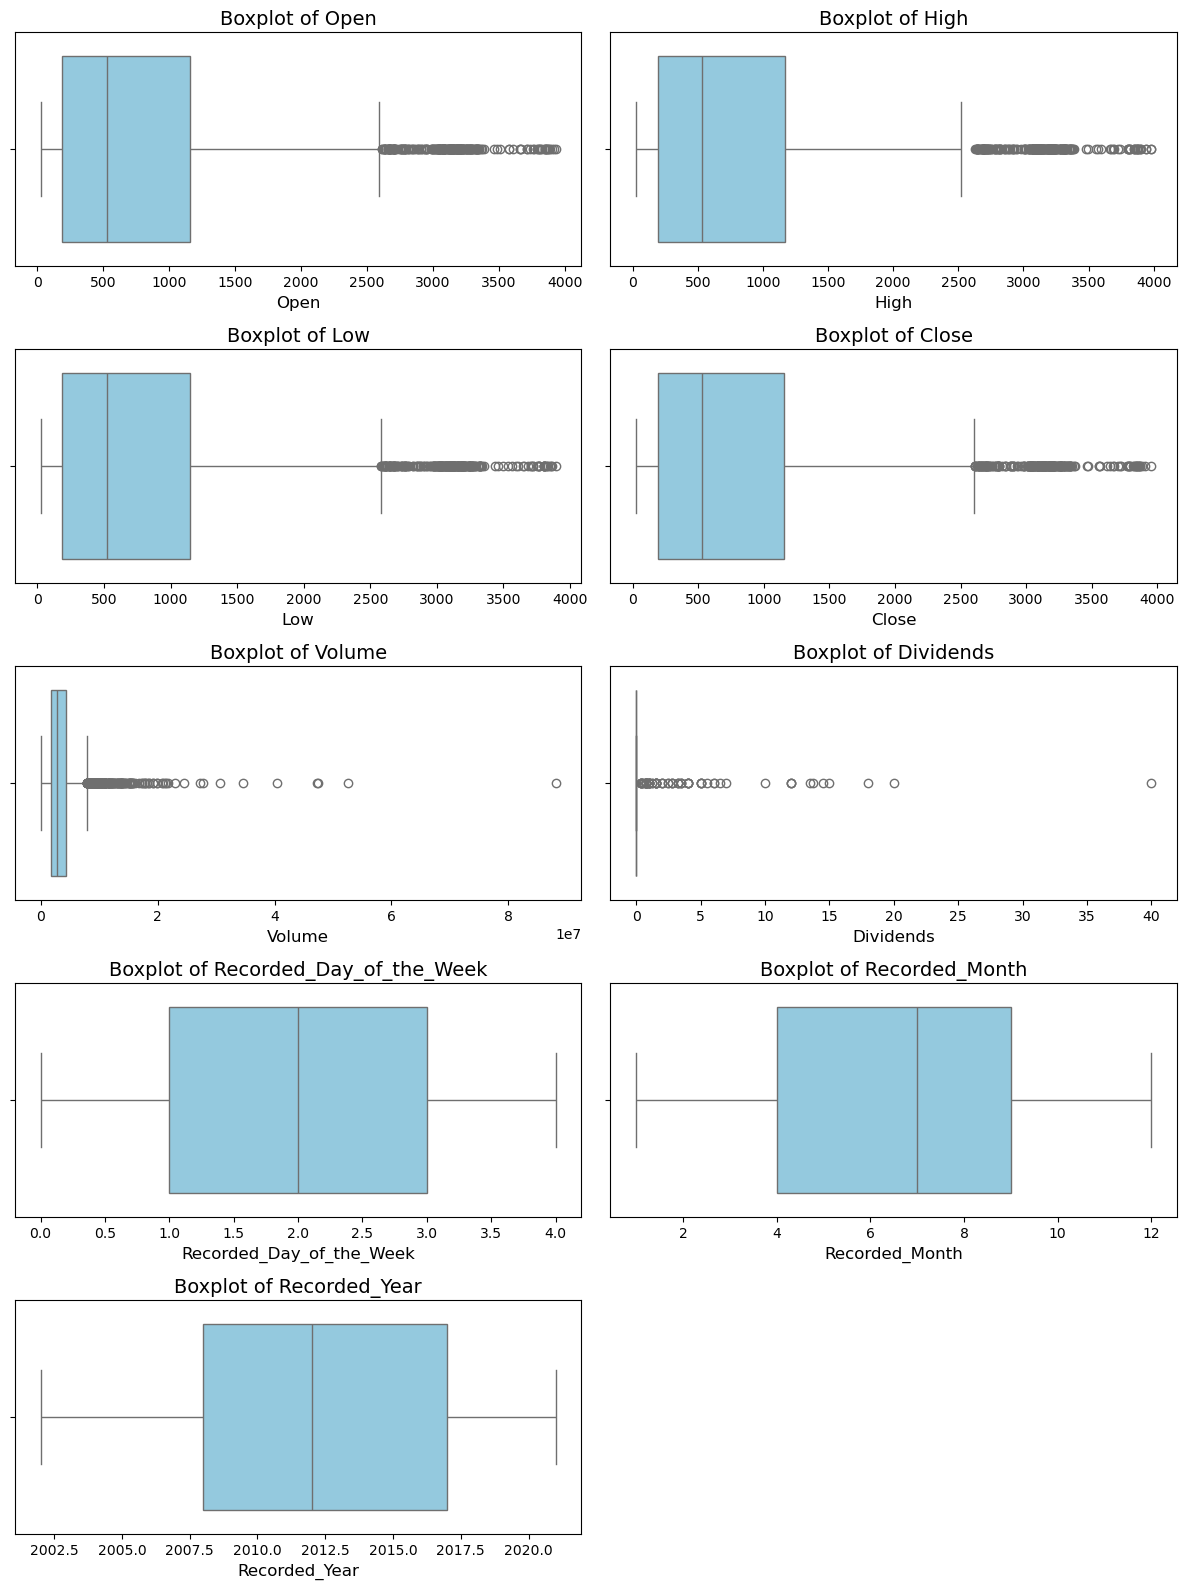

In [24]:
# Columns with outliers
outlier_cols = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Dividends',
    'Recorded_Day_of_the_Week',
    'Recorded_Month',
    'Recorded_Year',
]

# Setting up the figure
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 16))
axes = axes.flatten()

# Plot boxplots for each column
for i, col in enumerate(outlier_cols):
    sns.boxplot(x=df_tcs_stock_data[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f"Boxplot of {col}", fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].tick_params(axis='x', labelsize=10)

# Remove the empty subplot if number of columns < grid size
for j in range(len(outlier_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretation**

Here we can clearly see that there are certain columns which have outliers, now we will treat these outliers.

In [25]:
# Select numerical columns where outliers might be a problem
numerical_cols_for_outliers = ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends']

# For loop for iterating through these columns
for col in numerical_cols_for_outliers:
    # Finding Quartile 1
    Q1 = df_tcs_stock_data[col].quantile(0.25)

    # Finding Quartile 3
    Q3 = df_tcs_stock_data[col].quantile(0.75)

    # Finding the Interquartile range
    IQR = Q3 - Q1

    # Finding the Lower bound of the column
    lower_bound = Q1 - 1.5 * IQR

    # Finding the Upper bound of the column 
    upper_bound = Q3 + 1.5 * IQR

    # Capping the outliers
    df_tcs_stock_data[col] = np.clip(df_tcs_stock_data[col], lower_bound, upper_bound)

print("Outlier treatment complete.")

Outlier treatment complete.


#### Visualizing the **Outliers** in these columns again to check

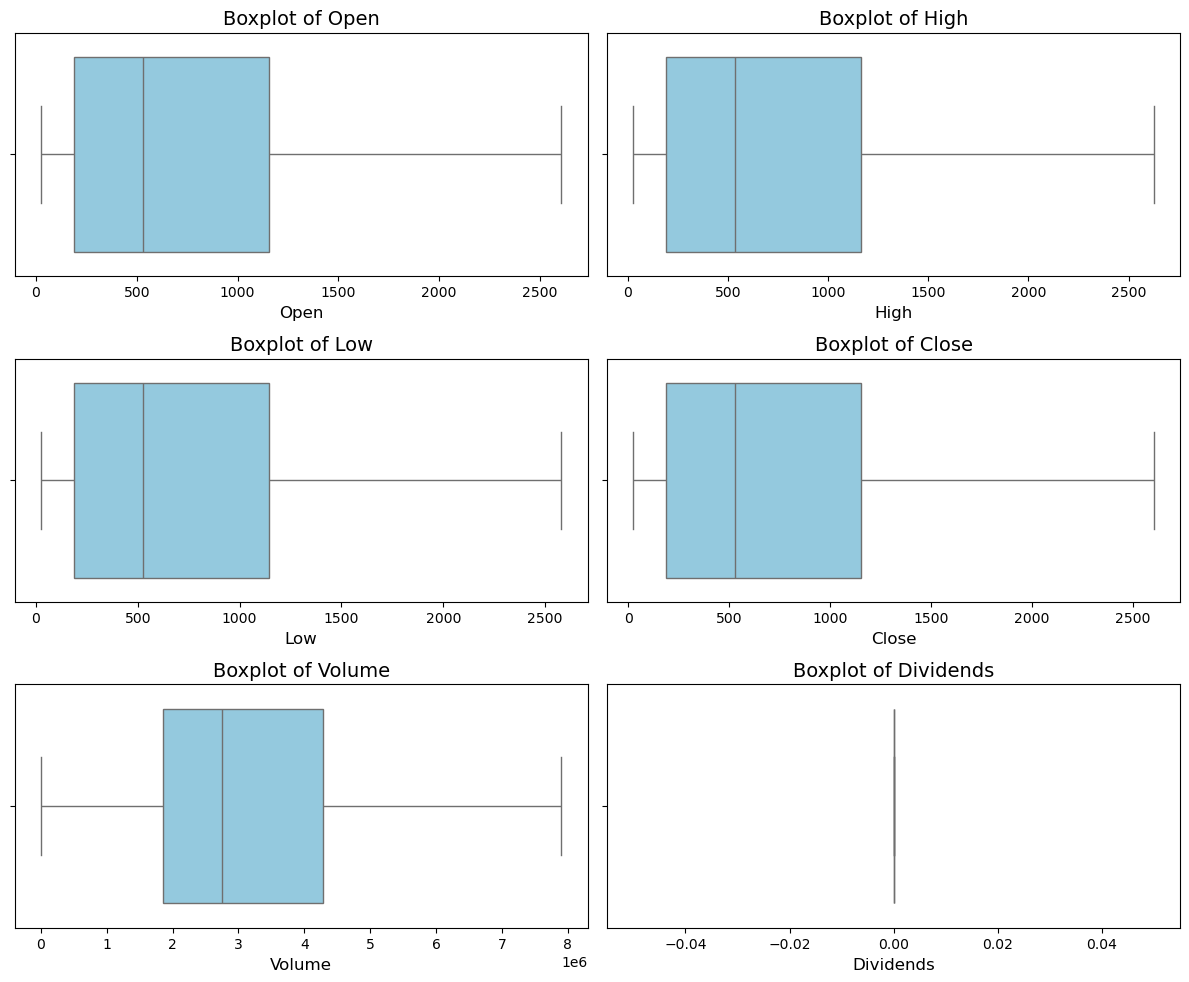

In [26]:
# Columns with outliers
outlier_cols = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Dividends']

# Setting up the figure
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 16))
axes = axes.flatten()

# Plot boxplots for each column
for i, col in enumerate(outlier_cols):
    sns.boxplot(x=df_tcs_stock_data[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f"Boxplot of {col}", fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].tick_params(axis='x', labelsize=10)

# Remove the empty subplot if number of columns < grid size
for j in range(len(outlier_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretation**

As we can see here in the above graphs that outliers are now treated in these columns.

## 3. Scaling, Encoding and Text data processing

First we will we split the dataset into **Dependent** and **Independent** variables.

In [27]:
# Sepearting X and y
X = df_tcs_stock_data.drop(columns = 'Close', axis = 1)
y = df_tcs_stock_data['Close']

# Making y a dataframe again
y = pd.DataFrame(data = y, columns = ['Close'])

In [28]:
# Checking X
X.head()

,Open,High,Low,Volume,Dividends,Recorded_Day_of_the_Week,Recorded_Month,Recorded_Year
0,28.79,29.74,28.79,212976,0.0,0,8,2002
1,29.56,30.03,28.91,153576,0.0,1,8,2002
2,29.18,29.18,26.56,822776,0.0,2,8,2002
3,27.11,27.11,27.11,0,0.0,3,8,2002
4,26.97,28.26,26.58,811856,0.0,4,8,2002


In [29]:
# Checking y
y.head()

,Close
0,29.52
1,29.12
2,27.11
3,27.11
4,27.05


### a. Encoding

As we don't have any categorical columns so we'll don't perform this step.

### b. Scaling

We will use **Standard Scaler**

In [30]:
# Seperating the Numerical columns
num_cols = X.select_dtypes(include = np.number)

# Initializing the StandardScaler
ss = StandardScaler()

# Scaling the numerical variables
scaled_values = ss.fit_transform(num_cols)

# Converting it back to dataframe
num_cols = pd.DataFrame(data = scaled_values, columns = num_cols.columns)

In [31]:
# Checking the num_cols
num_cols.head()

,Open,High,Low,Volume,Dividends,Recorded_Day_of_the_Week,Recorded_Month,Recorded_Year
0,-1.074664,-1.075715,-1.072862,-1.534237,0.0,-1.410982,0.425391,-1.907265
1,-1.073642,-1.075334,-1.072701,-1.563906,0.0,-0.702873,0.425391,-1.907265
2,-1.074146,-1.076452,-1.075855,-1.229652,0.0,0.005236,0.425391,-1.907265
3,-1.076894,-1.079175,-1.075117,-1.640615,0.0,0.713345,0.425391,-1.907265
4,-1.077080,-1.077662,-1.075828,-1.235106,0.0,1.421453,0.425391,-1.907265


## 4. Splitting the dataset into **Training** and **Testing** portion

In [32]:
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

**Interpretation**

Now our dataset is split on 70 30 proportion for training and testing data respectively

# Step 5: Training and Testing the model

## 1. Model Selection

In [33]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(random_state=1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=1, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=1),
    "xgb_model": xgb.XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6,
                            subsample=0.8, colsample_bytree=0.8, random_state=1, n_jobs=-1),
    "lgb_model": lgb.LGBMRegressor(n_estimators=300, learning_rate=0.1, max_depth=-1,
                              subsample=0.8, colsample_bytree=0.8, random_state=1, n_jobs=-1),
    "cat_model": CatBoostRegressor(iterations=300, learning_rate=0.1, depth=6,
                                  random_state=1, verbose=0)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R² Score': r2
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000223 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1059
[LightGBM] [Info] Number of data points in the train set: 3124, number of used features: 7
[LightGBM] [Info] Start training from score 835.832312


In [34]:
results_df = pd.DataFrame(results)
results_df.sort_values(by='R² Score', ascending=False)

,Model,MAE,RMSE,R² Score
0,Linear Regression,3.277495,5.575876,0.999946
1,Ridge Regression,3.277497,5.575880,0.999946
4,Random Forest,4.359960,8.034047,0.999887
7,lgb_model,5.012543,8.879764,0.999862
6,xgb_model,5.235543,9.892041,0.999829
5,Gradient Boosting,5.854339,9.912610,0.999828
3,Decision Tree,5.397804,10.317178,0.999814
8,cat_model,7.634661,12.113366,0.999744
2,Lasso Regression,7.139611,12.397703,0.999731


**Interpretation**

- **Linear Regression** achieved the highest R² Score (**0.999946**) with the lowest RMSE (**5.575876**) and MAE (**3.277495**), making it the best performing model overall.
- Rest of all the models have very similar R² Score but there is a significant difference between RMSE and MAE of different models.

**Conclusion**:  
- The best candidate is **Linear Regression** as it provides the most accurate predictions.  
- So for final deployment, **Linear Regression** would be recommended due to their higher predictive power an robustness.

## 2. Training the selected model

In [35]:
# Initializing the model
lr_model = LinearRegression()

# Training the model
lr_model.fit(X_train, y_train)

# Predicting on the test set
y_pred = lr_model.predict(X_test)

# Evaluating the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression MAE: {mae:.6f}")
print(f"Linear Regression RMSE: {rmse:.6f}")
print(f"Linear Regression R² Score: {r2:.6f}")

Linear Regression MAE: 3.277495
Linear Regression RMSE: 5.575876
Linear Regression R² Score: 0.999946


### &#8594; Hyperparameter tuning for Gradient Boosting Regressor

In [36]:
# Initializing the model
lr_tuned_model = LinearRegression()

# Defining parameter grid
param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False],
    'copy_X': [True, False],
    'tol': [1e-4, 1e-3, 1e-2, 1e-1]
}

# Initializing GridSearchCV
grid_search = GridSearchCV(
    estimator=lr_tuned_model,
    param_grid=param_grid,
    scoring='r2',      # Optimize for R² score
    cv=5,              # 5-fold cross-validation
    n_jobs=-1,
    verbose=2
)

# Training the model
grid_search.fit(X_train, y_train)

# Getting the best model and parameters
best_params_grid = grid_search.best_params_
best_score_grid = grid_search.best_score_

print("Best Parameters (GridSearch):", best_params_grid)
print("Best Cross-Validation R² Score (GridSearch):", best_score_grid)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters (GridSearch): {'copy_X': True, 'fit_intercept': True, 'positive': False, 'tol': 0.0001}
Best Cross-Validation R² Score (GridSearch): 0.9999152705225356


In [37]:
# Get the best model and parameters
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Cross-Validation R² Score:", best_score)

Best Parameters: {'copy_X': True, 'fit_intercept': True, 'positive': False, 'tol': 0.0001}
Best Cross-Validation R² Score: 0.9999152705225356


In [38]:
# Evaluating best model on test data
best_lr_model = grid_search.best_estimator_  # Extract best model

y_pred = best_lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test MAE: {mae:.6f}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test R² Score: {r2:.6f}")

Test MAE: 3.277495
Test RMSE: 5.575876
Test R² Score: 0.999946


**Interpretation**

#### **1. Best Parameters**
The GridSearchCV optimization selected the following hyperparameters (available in `grid_search.best_params_`):

- **`fit_intercept: True`** → The model includes an intercept term. This allows the regression line to shift vertically, which is important when the target variable is not centered around zero.  
- **`positive: False`** → Coefficients are not constrained to be positive. This gives the model flexibility to assign both positive and negative relationships between features and the target variable.  
- **`copy_X: True`** → The original training data is copied before fitting. This ensures the input data is not modified during training.  
- **`tol: 0.0001`** → The tolerance for the optimization solver. A smaller tolerance value leads to more precise convergence of the solution.

These parameter settings indicate that a standard Ordinary Least Squares regression (with intercept and no coefficient constraints) provided the best performance. The very small tolerance suggests precise convergence during optimization.

---

#### **2. Cross-Validation Performance**
- **Best Cross-Validation R² Score:** `0.999915`  

This means the model explains approximately **99.9915% of the variance** in the training data across the 5 cross-validation folds.  

Such an extremely high R² indicates:
- The relationship between features and target is highly linear.
- The model fits the training data exceptionally well.
- There is very strong consistency across different validation folds.

---

#### **3. Test Set Evaluation**
- **Test MAE (Mean Absolute Error):** `3.277495`  
  On average, the model’s predictions deviate from the true values by about **3.28 units**.

- **Test RMSE (Root Mean Squared Error):** `5.575876`  
  The typical prediction error magnitude is around **5.58 units**. Since RMSE penalizes larger errors more heavily than MAE, the slightly higher value suggests a few relatively larger deviations.

- **Test R² Score:** `0.999946`  
  The model explains approximately **99.9946% of the variance** in the unseen test data.

---

### **Overall Conclusion**

The Linear Regression model demonstrates **near-perfect performance** on both cross-validation and test data. The extremely high R² values and low error metrics suggest:

- The dataset likely has a very strong linear relationship.
- The model generalizes exceptionally well to unseen data.
- There is minimal evidence of overfitting, as training and test R² scores are very close.

This indicates that a simple linear model is highly suitable for this problem and captures the underlying data structure effectively.

## 3. Feature Selection

In [39]:
# Get feature names
feature_names = X_train.columns

# Flatten coefficients
coefficients = best_lr_model.coef_.ravel()

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute Coefficient': np.abs(coefficients)
})

# Sort by importance
top_features = importance_df.sort_values(
    by='Absolute Coefficient',
    ascending=False
).head(15)

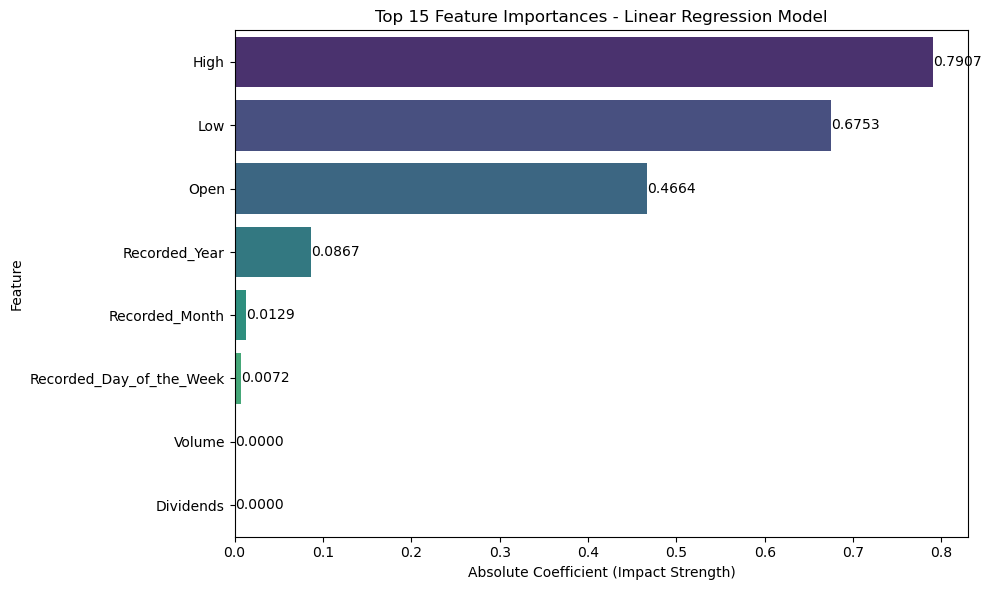

In [40]:
# Visualizing Linear Regression feature importance (using absolute coefficients)

plt.figure(figsize=(10,6))

bars = sns.barplot(
    x='Absolute Coefficient',
    y='Feature',
    data=top_features,
    palette='viridis'
)

plt.title("Top 15 Feature Importances - Linear Regression Model")
plt.xlabel("Absolute Coefficient (Impact Strength)")
plt.ylabel("Feature")

# Add value labels on bars
for container in bars.containers:
    plt.bar_label(container, fmt='%.4f')

plt.tight_layout()
plt.show()

**Interpretation**

We can see here that the following columns have **Strong Importance** on the model which are **`High`, `Low`, `Open`, `Recorded_year`**

So now we will Train and test the model on these features only to see if the accuracy improves even more.

## 4. Building the Final Model

In [41]:
# Select top 54 most important features
selected_features = ['High', 'Low', 'Open', 'Recorded_Year']

X_selected = df_tcs_stock_data[selected_features]

In [42]:
# Seperating the Numerical columns
num_cols = X_selected.select_dtypes(include = np.number)

# Initializing the StandardScaler
ss = StandardScaler()

# Scaling the numerical variables
scaled_values = ss.fit_transform(num_cols)

# Converting it back to dataframe
num_cols = pd.DataFrame(data = scaled_values, columns = num_cols.columns)

In [43]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state = 42)

# Initialize the model
final_lr_model = LinearRegression(copy_X = True, fit_intercept = True, positive = False, tol = 0.0001)

# Training the model
final_lr_model.fit(X_train, y_train)

# Predicting the X_test
y_pred = final_lr_model.predict(X_test)

# Checking the accuracy of the model
print("MAE:", mean_absolute_error(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
print("R² Score:", r2_score(y_test, y_pred))

MAE: 3.1374069551529353
RMSE: 5.0581034666327795
R² Score: 0.9999542301111405


**Interpretation**

We can see here that the R Square score has not increased much and not even decreased a bit.

So this will be the model deployed.

In [44]:
import pickle

# Save model
with open('final_lr_model.pkl', 'wb') as f:
    pickle.dump(final_lr_model, f)

# Save scaler
with open('standard_scaler_model.pkl', 'wb') as f:
    pickle.dump(ss, f)

print("Model and Scaler model saved successfully!")

Model and Scaler model saved successfully!
